# DB MoveOptimizer - Analyst → Optimizer Pipeline

Notebook 04 chains the two agents built in notebooks 02 and 03 into a single LangGraph pipeline.
Travel data goes in — a personalised subscription recommendation comes out.

**Pipeline flow:**
```
travel_data
    ↓
  analyst_node   (LLM: pattern summary, no tools)
    ↓ analyst_summary
  optimizer_node (LLM + lookup_subscriptions tool, ReAct loop)
    ↓
  recommendation
```

New concept introduced: **passing structured output between agents** via shared state,
and composing a simple linear agent with a ReAct agent in the same graph.

## Notebook Outline
1. Environment Setup
2. Load Mock Data & Subscription Catalog
3. Define Prompts, Tool, and State
4. Define Agent Nodes
5. Build & Compile the Pipeline Graph
6. Visualise the Graph
7. Run the Full Pipeline
8. Inspect the Message Trace

## 1. Environment Setup

In [1]:
import subprocess, sys, os

def install_packages(packages):
    for pkg in packages:
        try:
            __import__(pkg.split('==')[0].replace('-', '_'))
        except ImportError:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    print('✓ All packages ready')

install_packages(['openai', 'langgraph', 'langchain', 'langchain-core', 'langchain-openai', 'pandas'])

from openai import OpenAI

UNI_GPT_BASE_URL = 'https://chat.kiconnect.nrw/api/v1'
UNI_GPT_MODEL    = 'Openai GPT OSS 120B'
UNI_GPT_API_KEY  = os.getenv('UNI_GPT_API_KEY', '')

if not UNI_GPT_API_KEY:
    from getpass import getpass
    UNI_GPT_API_KEY = getpass('Enter your University GPT API Key: ')

print('✓ API client configured')


✓ All packages ready
✓ API client configured


## 2. Load Mock Data & Subscription Catalog

In [2]:
import json as _json
import pandas as pd
from pathlib import Path

# --- Mock user (same as notebook 02) ---
MOCK_USER = {
    'user_id': 'USR-0042',
    'name': 'Anna Müller',
    'current_subscriptions': ['BahnCard 25 (2nd class)'],
    'travel_log': [
        {'date': '2026-05-02', 'origin': 'Köln Hbf',    'destination': 'Frankfurt Hbf',   'ticket_type': 'Flexpreis',          'price_eur': 89.00, 'class': 2},
        {'date': '2026-05-09', 'origin': 'Frankfurt Hbf','destination': 'Köln Hbf',        'ticket_type': 'Sparpreis',          'price_eur': 17.90, 'class': 2},
        {'date': '2026-05-16', 'origin': 'Köln Hbf',    'destination': 'Frankfurt Hbf',   'ticket_type': 'Flexpreis',          'price_eur': 89.00, 'class': 2},
        {'date': '2026-05-23', 'origin': 'Frankfurt Hbf','destination': 'Düsseldorf Hbf',  'ticket_type': 'Deutschlandticket', 'price_eur': 49.00, 'class': 2},
        {'date': '2026-05-30', 'origin': 'Köln Hbf',    'destination': 'Frankfurt Hbf',   'ticket_type': 'Sparpreis',          'price_eur': 24.90, 'class': 2},
    ]
}

# --- Subscription catalog (same as notebook 03) ---
catalog_df = pd.read_csv(Path('../data/subscriptions.csv'))

print(f'✓ User loaded: {MOCK_USER["name"]} ({MOCK_USER["user_id"]})')
print(f'✓ Catalog loaded: {len(catalog_df)} products')


✓ User loaded: Anna Müller (USR-0042)
✓ Catalog loaded: 7 products


## 3. Define Prompts, Tool, and State

### Shared State
The pipeline state carries three fields:
- `travel_data` — raw user input, set once at the start
- `analyst_summary` — written by the analyst node, read by the optimizer node
- `messages` — the optimizer's tool-loop message history (uses `add_messages` reducer)

This is the key pattern for multi-agent chaining: **each agent reads from and writes to
named fields in a shared state dict**, rather than passing return values directly.

In [3]:
from typing import Annotated, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


# --- Shared pipeline state ---
class PipelineState(TypedDict):
    travel_data:      dict                        # input
    analyst_summary:  str                         # analyst → optimizer handoff
    messages:         Annotated[list, add_messages]  # optimizer tool loop


# --- Analyst system prompt (from notebook 02) ---
ANALYST_PROMPT = """You are a Deutsche Bahn mobility analyst.
Review the user's travel log and respond with exactly these four sections:
1. DOMINANT ROUTE — most frequent origin-destination pair
2. TICKET MIX — breakdown of ticket types used
3. SPEND SUMMARY — total spend and average cost per trip
4. ONE OBSERVATION — a single sentence noting an inefficiency or opportunity
Be factual and brief. Do not make recommendations."""


# --- Optimizer system prompt (from notebook 03) ---
OPTIMIZER_PROMPT = """You are a Deutsche Bahn mobility optimizer.
You receive an analyst summary of a user's travel behaviour.
Use the lookup_subscriptions tool to retrieve the current product catalog,
then recommend the single best subscription change for this user.
Show the expected annual saving. Be concise — three sentences maximum."""


# --- Tool (from notebook 03) ---
@tool
def lookup_subscriptions(filter_type: str = 'all') -> str:
    """Look up Deutsche Bahn subscription products from the catalog.

    Args:
        filter_type: 'card', 'subscription', or 'all'.

    Returns:
        Formatted table of matching DB products with prices and conditions.
    """
    df = catalog_df.copy()
    if filter_type != 'all':
        df = df[df['type'] == filter_type]
    return df.to_string(index=False) if not df.empty else f"No products for '{filter_type}'."


tools = [lookup_subscriptions]

print('✓ PipelineState defined')
print('✓ ANALYST_PROMPT defined')
print('✓ OPTIMIZER_PROMPT defined')
print('✓ lookup_subscriptions tool defined')


✓ PipelineState defined
✓ ANALYST_PROMPT defined
✓ OPTIMIZER_PROMPT defined
✓ lookup_subscriptions tool defined


## 4. Define Agent Nodes

Two distinct nodes, two distinct roles:
- **`analyst_node`** — plain LLM call, no tools. Writes `analyst_summary` to state.
- **`optimizer_node`** — LLM with tools bound. On first call it builds its initial message
  from `analyst_summary`; on subsequent calls (after a tool result) it continues from
  the existing message history.

In [4]:
# Plain LLM for the analyst (no tools needed)
llm = ChatOpenAI(
    model=UNI_GPT_MODEL,
    openai_api_key=UNI_GPT_API_KEY,
    openai_api_base=UNI_GPT_BASE_URL,
    temperature=0.0,
)

# LLM with tools for the optimizer
llm_with_tools = llm.bind_tools(tools)


def format_travel_data(user: dict) -> str:
    """Serialise a user travel record into a prompt-ready string."""
    subs  = ', '.join(user.get('current_subscriptions', []))
    trips = _json.dumps(user.get('travel_log', []), indent=2, ensure_ascii=False)
    return (
        f"Analyse the travel log for {user['name']} ({user['user_id']}).\n"
        f"Current subscriptions: {subs}\n\n"
        f"Travel log (JSON):\n{trips}"
    )


def analyst_node(state: PipelineState) -> dict:
    """Run the Analyst: pattern detection from the travel log."""
    print('► Analyst running...')
    user_msg  = format_travel_data(state['travel_data'])
    response  = llm.invoke([
        SystemMessage(content=ANALYST_PROMPT),
        HumanMessage(content=user_msg),
    ])
    summary = response.content
    print('✓ Analyst complete')
    print(f'\n{"─" * 50}\nANALYST SUMMARY\n{"─" * 50}\n{summary}\n{"─" * 50}\n')
    return {'analyst_summary': summary}


def optimizer_node(state: PipelineState) -> dict:
    """Run the Optimizer: look up catalog and recommend the best subscription."""
    # First entry: build the initial user message from the analyst handoff
    if not state['messages']:
        print('► Optimizer running (first call)...')
        initial_msg = HumanMessage(content=(
            'Based on the analyst summary below, recommend the best DB subscription.\n'
            'Use the lookup_subscriptions tool to check the catalog before answering.\n\n'
            f'ANALYST SUMMARY:\n{state["analyst_summary"]}'
        ))
        history = [initial_msg]
    else:
        print('► Optimizer running (after tool result)...')
        history = state['messages']

    response = llm_with_tools.invoke(
        [SystemMessage(content=OPTIMIZER_PROMPT)] + history
    )
    return {'messages': history + [response]} if not state['messages'] else {'messages': [response]}


print('✓ analyst_node defined')
print('✓ optimizer_node defined')


✓ analyst_node defined
✓ optimizer_node defined


## 5. Build & Compile the Pipeline Graph

The analyst is a simple pass-through node. The optimizer uses the same ReAct loop
from notebook 03. Both share a single `PipelineState`.

In [5]:
tool_node = ToolNode(tools)

workflow = StateGraph(PipelineState)

workflow.add_node('analyst',   analyst_node)
workflow.add_node('optimizer', optimizer_node)
workflow.add_node('tools',     tool_node)

# Linear: analyst always runs first
workflow.add_edge(START,       'analyst')
workflow.add_edge('analyst',   'optimizer')

# ReAct loop on the optimizer
workflow.add_conditional_edges('optimizer', tools_condition)
workflow.add_edge('tools', 'optimizer')

graph = workflow.compile()

print('✓ Pipeline graph compiled')


✓ Pipeline graph compiled


## 6. Visualise the Graph

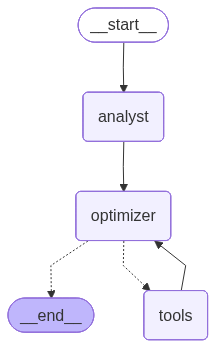

In [9]:
from IPython.display import display, Image

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

## 7. Run the Full Pipeline

One function call. The graph handles the agent sequencing internally.

In [7]:
initial_state = {
    'travel_data':     MOCK_USER,
    'analyst_summary': '',
    'messages':        [],
}

print('=' * 60)
print(f'Running pipeline for: {MOCK_USER["name"]} ({MOCK_USER["user_id"]})')
print('=' * 60 + '\n')

result = graph.invoke(initial_state)

print('\n' + '=' * 60)
print('FINAL RECOMMENDATION')
print('=' * 60)
print(result['messages'][-1].content)
print('=' * 60)


Running pipeline for: Anna Müller (USR-0042)

► Analyst running...
✓ Analyst complete

──────────────────────────────────────────────────
ANALYST SUMMARY
──────────────────────────────────────────────────
**DOMINANT ROUTE** – Köln Hbf → Frankfurt Hbf (3 trips)  

**TICKET MIX** – Flexpreis: 2 × (40 %) | Sparpreis: 2 × (40 %) | Deutschlandticket: 1 × (20 %)  

**SPEND SUMMARY** – Total spend: **€269.80**; Average cost per trip: **≈ €53.96**  

**ONE OBSERVATION** – The Köln‑Frankfurt leg is frequently booked with full‑price Flexpreis tickets despite cheaper Sparpreis options being available.
──────────────────────────────────────────────────

► Optimizer running (first call)...
► Optimizer running (after tool result)...

FINAL RECOMMENDATION
Based on your five trips (2 × Flexpreis, 2 × Sparpreis, 1 × Deutschland‑Ticket) the only card that comes close to paying for itself is the **BahnCard 25 (2nd class)** – €57.90 per year. It would give you a 25 % discount on the four long‑distance tic

## 8. Inspect the Message Trace

Print every message in the pipeline to see both the analyst→optimizer handoff
and the optimizer's internal tool-call loop.

In [8]:
print(f'Analyst summary:\n{result["analyst_summary"]}\n')
print(f'Optimizer message trace ({len(result["messages"])} messages):')

for i, msg in enumerate(result['messages']):
    role            = type(msg).__name__
    content_preview = str(msg.content)[:200].replace('\n', ' ')
    tool_calls      = getattr(msg, 'tool_calls', [])
    print(f'  [{i}] {role}')
    if tool_calls:
        print(f'       tool_calls: {[tc["name"] for tc in tool_calls]}')
    print(f'       content: {content_preview}')
    print()


Analyst summary:
**DOMINANT ROUTE** – Köln Hbf → Frankfurt Hbf (3 trips)  

**TICKET MIX** – Flexpreis: 2 × (40 %) | Sparpreis: 2 × (40 %) | Deutschlandticket: 1 × (20 %)  

**SPEND SUMMARY** – Total spend: **€269.80**; Average cost per trip: **≈ €53.96**  

**ONE OBSERVATION** – The Köln‑Frankfurt leg is frequently booked with full‑price Flexpreis tickets despite cheaper Sparpreis options being available.

Optimizer message trace (4 messages):
  [0] HumanMessage
       content: Based on the analyst summary below, recommend the best DB subscription. Use the lookup_subscriptions tool to check the catalog before answering.  ANALYST SUMMARY: **DOMINANT ROUTE** – Köln Hbf → Frank

  [1] AIMessage
       tool_calls: ['lookup_subscriptions']
       content: 

  [2] ToolMessage
       content: product_id             product_name type  monthly_cost_eur  annual_cost_eur  discount_pct  travel_class           coverage_scope  min_commitment_months                                                 

